# Data Preparation Lab

**Course:** Introduction to Computer Vision

**Goal:** I clean the data with a focus on missing values and basic quality checks.

**Dataset:** I load all CSV files from `Dataset/` in **low‑memory mode**. I build a **sample dataframe** (`df`) for plots and checks, while missing‑value rates are computed on the **full dataset** using chunked reads. The final cleaned CSV is written in chunks to avoid memory errors.

### Environment

This notebook uses **chunked CSV reading** (no `pyarrow` required).

**If it feels slow or triggers a MemoryError:** restart the kernel, then lower `CSV_READ_CHUNKSIZE` (e.g. 50_000 or 25_000) or reduce `MAX_SAMPLE_ROWS`.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import gc
from pandas.errors import ParserError

# Fewer implicit copies (pandas 2.x)
pd.options.mode.copy_on_write = True

DATA_DIR = Path("Dataset")

# Low-memory settings
CSV_READ_CHUNKSIZE = 50_000
MAX_SAMPLE_ROWS = 200_000

csv_files = sorted(f for f in DATA_DIR.glob("*.csv") if "clean" not in f.name.lower())
if not csv_files:
    raise FileNotFoundError("No raw CSV files found in Dataset/")


def iter_csv_chunks(file_path, chunksize):
    """Robust CSV reader: fallback to python engine if C engine runs out of memory."""
    try:
        for chunk in pd.read_csv(
            file_path,
            chunksize=chunksize,
            low_memory=True,
            engine="c",
            memory_map=False,
        ):
            yield chunk
    except (ParserError, MemoryError, OSError) as e:
        print(f"Fallback reader for {file_path.name}: {type(e).__name__}")
        safe_chunk = max(20_000, chunksize // 2)
        for chunk in pd.read_csv(
            file_path,
            chunksize=safe_chunk,
            low_memory=True,
            engine="python",
            on_bad_lines="skip",
        ):
            yield chunk


# Build union of columns across all CSVs
all_columns = []
for f in csv_files:
    try:
        cols = list(pd.read_csv(f, nrows=0, engine="c").columns)
    except Exception:
        cols = list(pd.read_csv(f, nrows=0, engine="python").columns)
    for c in cols:
        if c not in all_columns:
            all_columns.append(c)

# Pass 1: compute missing counts on the full dataset + build a sample for plots
missing_count = pd.Series(0, index=all_columns, dtype="int64")
total_rows = 0
sample_frames = []
current_sample = 0

for f in csv_files:
    for chunk in iter_csv_chunks(f, CSV_READ_CHUNKSIZE):
        chunk = chunk.reindex(columns=all_columns)
        total_rows += len(chunk)
        missing_count = missing_count.add(chunk.isna().sum(), fill_value=0)

        if current_sample < MAX_SAMPLE_ROWS:
            take = min(1000, len(chunk), MAX_SAMPLE_ROWS - current_sample)
            if take > 0:
                sample_frames.append(chunk.sample(n=take, random_state=42))
                current_sample += take

        del chunk
        gc.collect()

# Sample dataframe used for plots and previews
if sample_frames:
    df = pd.concat(sample_frames, ignore_index=True)
else:
    df = pd.DataFrame(columns=all_columns)

missing_percent = (missing_count / max(total_rows, 1)) * 100
missing_summary = (
    pd.DataFrame({"missing_count": missing_count, "missing_percent": missing_percent})
    .sort_values("missing_percent", ascending=False)
)

print("Loaded files:")
for f in csv_files:
    print("-", f.name)

print(f"Total rows (all files): {total_rows:,}")
print(f"Sample rows (df): {len(df):,}")
print("Total columns:", len(all_columns))

df.head()

C:\Users\gemim\AppData\Local\Temp\ipykernel_24116\998400250.py:24: DtypeWarning: Columns (51) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
C:\Users\gemim\AppData\Local\Temp\ipykernel_24116\998400250.py:24: DtypeWarning: Columns (24,51) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
C:\Users\gemim\AppData\Local\Temp\ipykernel_24116\998400250.py:24: DtypeWarning: Columns (51) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
C:\Users\gemim\AppData\Local\Temp\ipykernel_24116\998400250.py:24: DtypeWarning: Columns (24,51) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
C:\Users\gemim\AppData\Local\Temp\ipykernel_24116\998400250.py:24: DtypeWarning: Columns (51) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
C:\Users\gemim

Loaded files:
- NFL Play by Play 2009-2016 (v3).csv
- NFL Play by Play 2009-2017 (v4).csv
- NFL Play by Play 2009-2018 (v5).csv
Total rows (all files): 1,219,506
Sample rows (df): 26,000
Total columns: 348


,Date,GameID,Drive,qtr,down,time,TimeUnder,TimeSecs,PlayTimeDiff,SideofField,...,penalty_player_id,penalty_player_name,penalty_yards,replay_or_challenge,replay_or_challenge_result,penalty_type,defensive_two_point_attempt,defensive_two_point_conv,defensive_extra_point_attempt,defensive_extra_point_conv
0,2009-12-10,2.009121e+09,10.0,2,1.0,06:06,7.0,2166.0,37.0,PIT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-10-04,2.009100e+09,22.0,4,1.0,05:50,6.0,350.0,6.0,NYG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-09-13,2.009091e+09,4.0,1,3.0,05:45,6.0,3045.0,36.0,CLE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-10-11,2.009101e+09,19.0,3,1.0,06:41,7.0,1301.0,41.0,JAC,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-12-27,2.009123e+09,14.0,2,NaN,00:18,1.0,1818.0,6.0,BAL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Overview and missing values

I report the shape of the **sample** `df` and missing values computed on the **full dataset** (chunked pass).

In [2]:
print(f"Total rows (all files): {total_rows:,}")
print(f"Sample rows (df): {len(df):,}")
print("Total columns:", len(all_columns))

missing_summary.head(15)

Total rows (all files): 1,219,506
Sample rows (df): 26,000
Total columns: 348


,missing_count,missing_percent
lateral_sack_player_name,1219506,100.000000
assist_tackle_4_player_name,1219506,100.000000
assist_tackle_4_player_id,1219506,100.000000
lateral_sack_player_id,1219506,100.000000
assist_tackle_4_team,1219506,100.000000
assist_tackle_3_player_name,1219503,99.999754
assist_tackle_3_player_id,1219503,99.999754
assist_tackle_3_team,1219503,99.999754
tackle_for_loss_2_player_id,1219498,99.999344
tackle_for_loss_2_player_name,1219498,99.999344


## 2. Drop high-missing columns

I drop columns with more than **75%** missing values.

In [3]:
threshold = 75.0
cols_to_drop = missing_percent[missing_percent > threshold].index

print("Columns to drop:", len(cols_to_drop))

# Drop high-missing columns (sample only, for plots)
reduced_df = df.drop(columns=cols_to_drop)
print("Remaining columns:", reduced_df.shape[1])
reduced_df.head()

Columns to drop: 132
Remaining columns: 216


,Date,GameID,Drive,qtr,down,time,TimeUnder,TimeSecs,PlayTimeDiff,SideofField,...,lateral_reception,lateral_rush,lateral_return,lateral_recovery,return_yards,replay_or_challenge,defensive_two_point_attempt,defensive_two_point_conv,defensive_extra_point_attempt,defensive_extra_point_conv
0,2009-12-10,2.009121e+09,10.0,2,1.0,06:06,7.0,2166.0,37.0,PIT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-10-04,2.009100e+09,22.0,4,1.0,05:50,6.0,350.0,6.0,NYG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-09-13,2.009091e+09,4.0,1,3.0,05:45,6.0,3045.0,36.0,CLE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-10-11,2.009101e+09,19.0,3,1.0,06:41,7.0,1301.0,41.0,JAC,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-12-27,2.009123e+09,14.0,2,NaN,00:18,1.0,1818.0,6.0,BAL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Impute remaining missing values

I impute remaining gaps with the **median** (numeric) and **mode** (categorical) on the **sample** `df`.

In [4]:
from pandas.api.types import is_numeric_dtype

clean_df = reduced_df.copy()

dtypes = clean_df.dtypes
_num_mask = dtypes.map(is_numeric_dtype)
numeric_cols = dtypes[_num_mask].index
categorical_cols = dtypes[~_num_mask].index

for col in numeric_cols:
    med = clean_df[col].median()
    clean_df[col] = clean_df[col].fillna(med)

for col in categorical_cols:
    mode = clean_df[col].mode(dropna=True)
    fill_val = mode.iloc[0] if len(mode) > 0 else "Unknown"
    clean_df[col] = clean_df[col].fillna(fill_val)

clean_df.isna().sum().sort_values(ascending=False).head(10)

Date                      0
total_home_pass_wpa       0
total_home_raw_yac_epa    0
total_away_raw_yac_epa    0
wp                        0
def_wp                    0
home_wp                   0
away_wp                   0
wpa                       0
home_wp_post              0
dtype: int64

## 4. Deduplicate and save the cleaned dataset (chunked + compressed)

I export the cleaned table in **chunks** and **gzip compression** to save disk space. Duplicates are removed **per chunk** (approximate global deduplication). If space is very limited, the cell automatically switches to a **tiny export mode**.

In [5]:
from pandas.api.types import is_numeric_dtype
import shutil

# Compute fill values from the sample
sample_dtypes = reduced_df.dtypes
_num_mask = sample_dtypes.map(is_numeric_dtype)
numeric_cols = sample_dtypes[_num_mask].index.tolist()
categorical_cols = sample_dtypes[~_num_mask].index.tolist()

numeric_medians = reduced_df[numeric_cols].median()
cat_fill = {}
for col in categorical_cols:
    mode = reduced_df[col].mode(dropna=True)
    cat_fill[col] = mode.iloc[0] if len(mode) > 0 else "Unknown"

# Safer export settings when disk space is limited
OUTPUT_PATH = "Dataset/cleaned_primary_schema.csv.gz"
MIN_FREE_GB = 0.10
MAX_EXPORT_ROWS = 300_000  # set None to export everything
MAX_EXPORT_COLS = None  # set e.g. 80 to export fewer columns

free_bytes = shutil.disk_usage(".").free
free_gb = free_bytes / (1024**3)
print(f"Free disk space before export: {free_gb:.2f} GB")

# Automatic fallback when disk is almost full
if free_gb < MIN_FREE_GB:
    OUTPUT_PATH = "Dataset/cleaned_primary_schema_tiny.csv.gz"
    MAX_EXPORT_ROWS = 20_000
    MAX_EXPORT_COLS = 80
    print(
        "Low disk space detected -> tiny export mode: "
        f"rows={MAX_EXPORT_ROWS}, cols={MAX_EXPORT_COLS}, file={OUTPUT_PATH}"
    )

first = True
written_rows = 0

try:
    for f in csv_files:
        for chunk in iter_csv_chunks(f, CSV_READ_CHUNKSIZE):
            chunk = chunk.reindex(columns=all_columns)
            chunk = chunk.drop(columns=cols_to_drop)

            if MAX_EXPORT_COLS is not None:
                keep_cols = chunk.columns[:MAX_EXPORT_COLS]
                chunk = chunk[keep_cols]

            for col in numeric_cols:
                if col in chunk.columns:
                    chunk[col] = chunk[col].fillna(numeric_medians.get(col))

            for col in categorical_cols:
                if col in chunk.columns:
                    chunk[col] = chunk[col].fillna(cat_fill.get(col, "Unknown"))

            chunk = chunk.drop_duplicates()

            if MAX_EXPORT_ROWS is not None:
                remaining = MAX_EXPORT_ROWS - written_rows
                if remaining <= 0:
                    break
                if len(chunk) > remaining:
                    chunk = chunk.iloc[:remaining]

            chunk.to_csv(
                OUTPUT_PATH,
                mode="w" if first else "a",
                index=False,
                header=first,
                compression="gzip",
            )

            written_rows += len(chunk)
            first = False
            del chunk
            gc.collect()

        if MAX_EXPORT_ROWS is not None and written_rows >= MAX_EXPORT_ROWS:
            break

except OSError as e:
    if "No space left on device" in str(e):
        raise RuntimeError(
            "Disk full during export. Free some space and re-run this cell. "
            "You can also reduce MAX_EXPORT_ROWS."
        ) from e
    raise

print(f"Rows exported: {written_rows:,}")
OUTPUT_PATH

Free disk space before export: 0.16 GB


C:\Users\gemim\AppData\Local\Temp\ipykernel_24116\998400250.py:24: DtypeWarning: Columns (51) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
C:\Users\gemim\AppData\Local\Temp\ipykernel_24116\998400250.py:24: DtypeWarning: Columns (24,51) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
C:\Users\gemim\AppData\Local\Temp\ipykernel_24116\998400250.py:24: DtypeWarning: Columns (51) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
C:\Users\gemim\AppData\Local\Temp\ipykernel_24116\998400250.py:24: DtypeWarning: Columns (24,51) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
C:\Users\gemim\AppData\Local\Temp\ipykernel_24116\998400250.py:24: DtypeWarning: Columns (51) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
C:\Users\gemim

Rows exported: 300,000


'Dataset/cleaned_primary_schema.csv.gz'

## 5. Visualizations

I split the visual analysis into separate subsections so each result is easy to read.

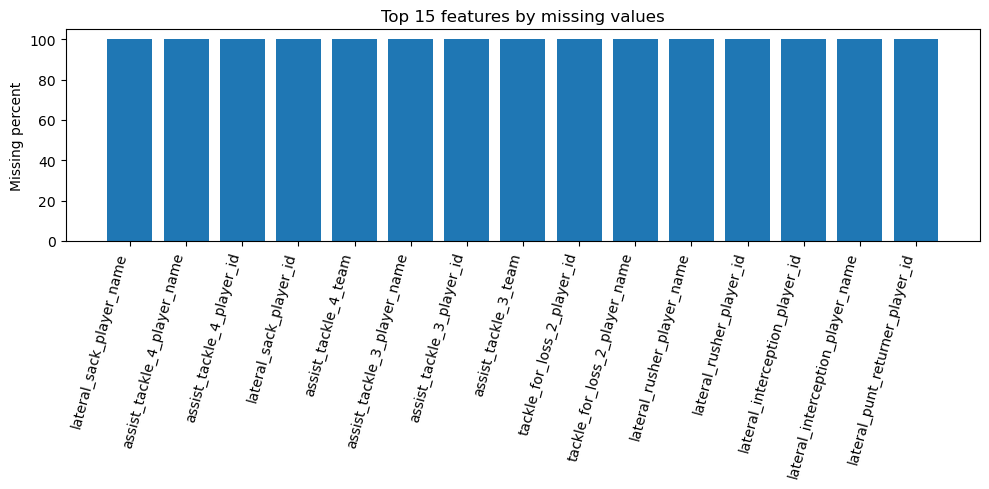

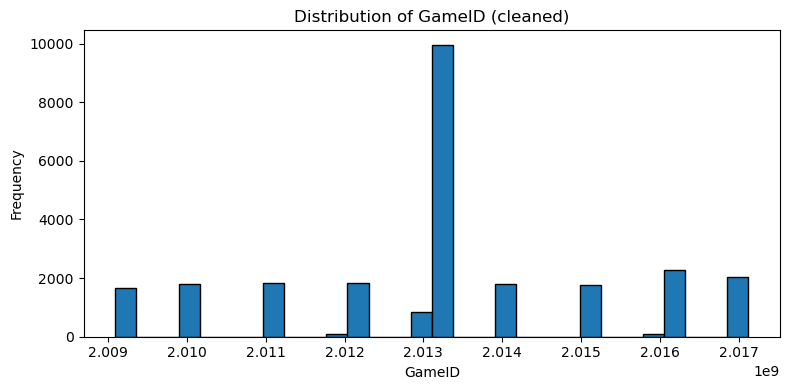

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 5.0 Missing values bar chart
top_missing = missing_summary.head(15)
plt.figure(figsize=(10, 5))
plt.bar(top_missing.index.astype(str), top_missing["missing_percent"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("Missing percent")
plt.title("Top 15 features by missing values")
plt.tight_layout()
plt.show()

# 5.0 Histogram of first numeric feature
num_cols = clean_df.select_dtypes(include=[np.number]).columns
if len(num_cols) > 0:
    col = num_cols[0]
    plt.figure(figsize=(8, 4))
    plt.hist(clean_df[col], bins=30, edgecolor="black")
    plt.title(f"Distribution of {col} (cleaned)")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

### 5.1 Correlation and boxplots

I inspect linear relationships and outliers on selected numeric features.

Run the next code cell for the heatmap and boxplots.

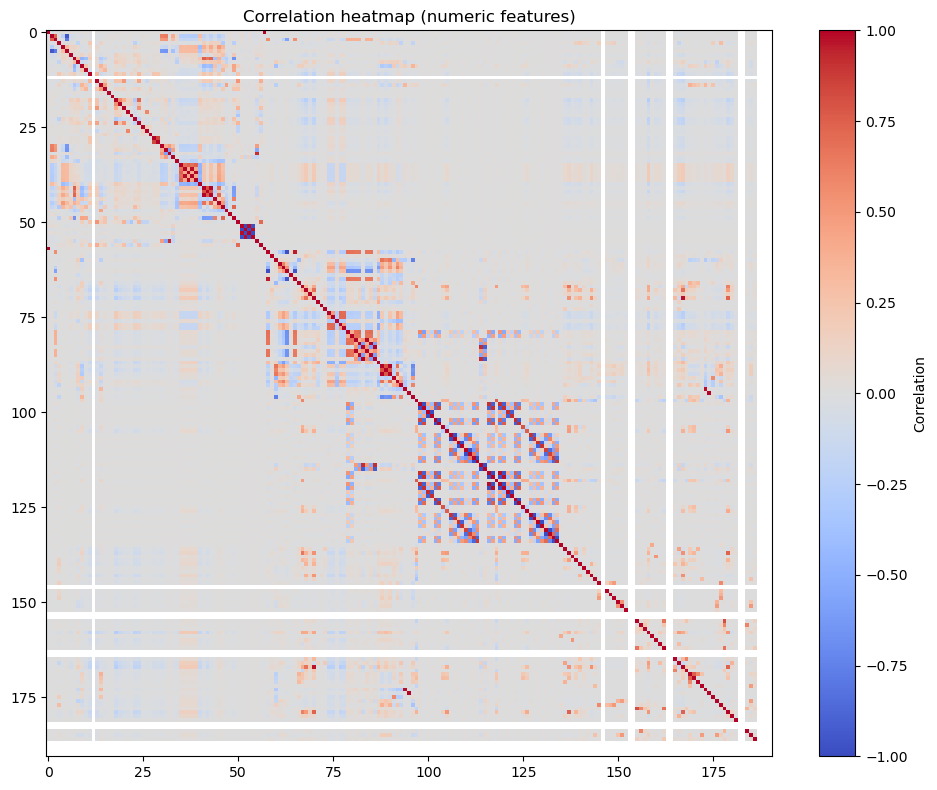

<Figure size 1000x500 with 0 Axes>

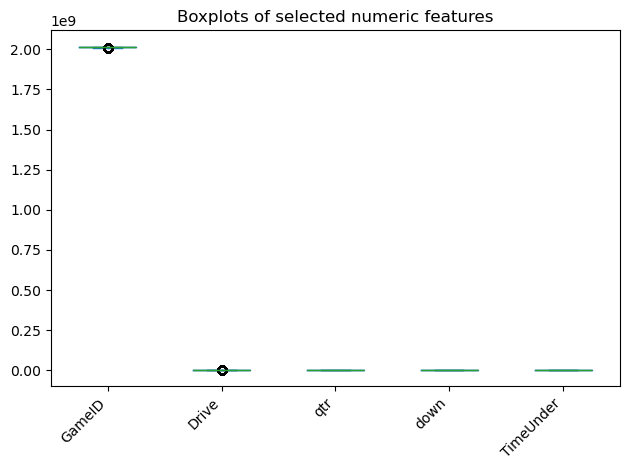

In [7]:
num_cols = clean_df.select_dtypes(include=[np.number]).columns

if len(num_cols) > 1:
    corr = clean_df[num_cols].corr()
    plt.figure(figsize=(10, 8))
    plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(label="Correlation")
    plt.title("Correlation heatmap (numeric features)")
    plt.tight_layout()
    plt.show()

if len(num_cols) > 0:
    cols_for_boxplot = list(num_cols[:5])
    plt.figure(figsize=(10, 5))
    clean_df[cols_for_boxplot].plot(kind="box")
    plt.title("Boxplots of selected numeric features")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

### 5.2 Pairplot and class distribution

I visualize pairwise relations and one low-cardinality categorical distribution.

Run the next code cell for pairplot and class distribution.

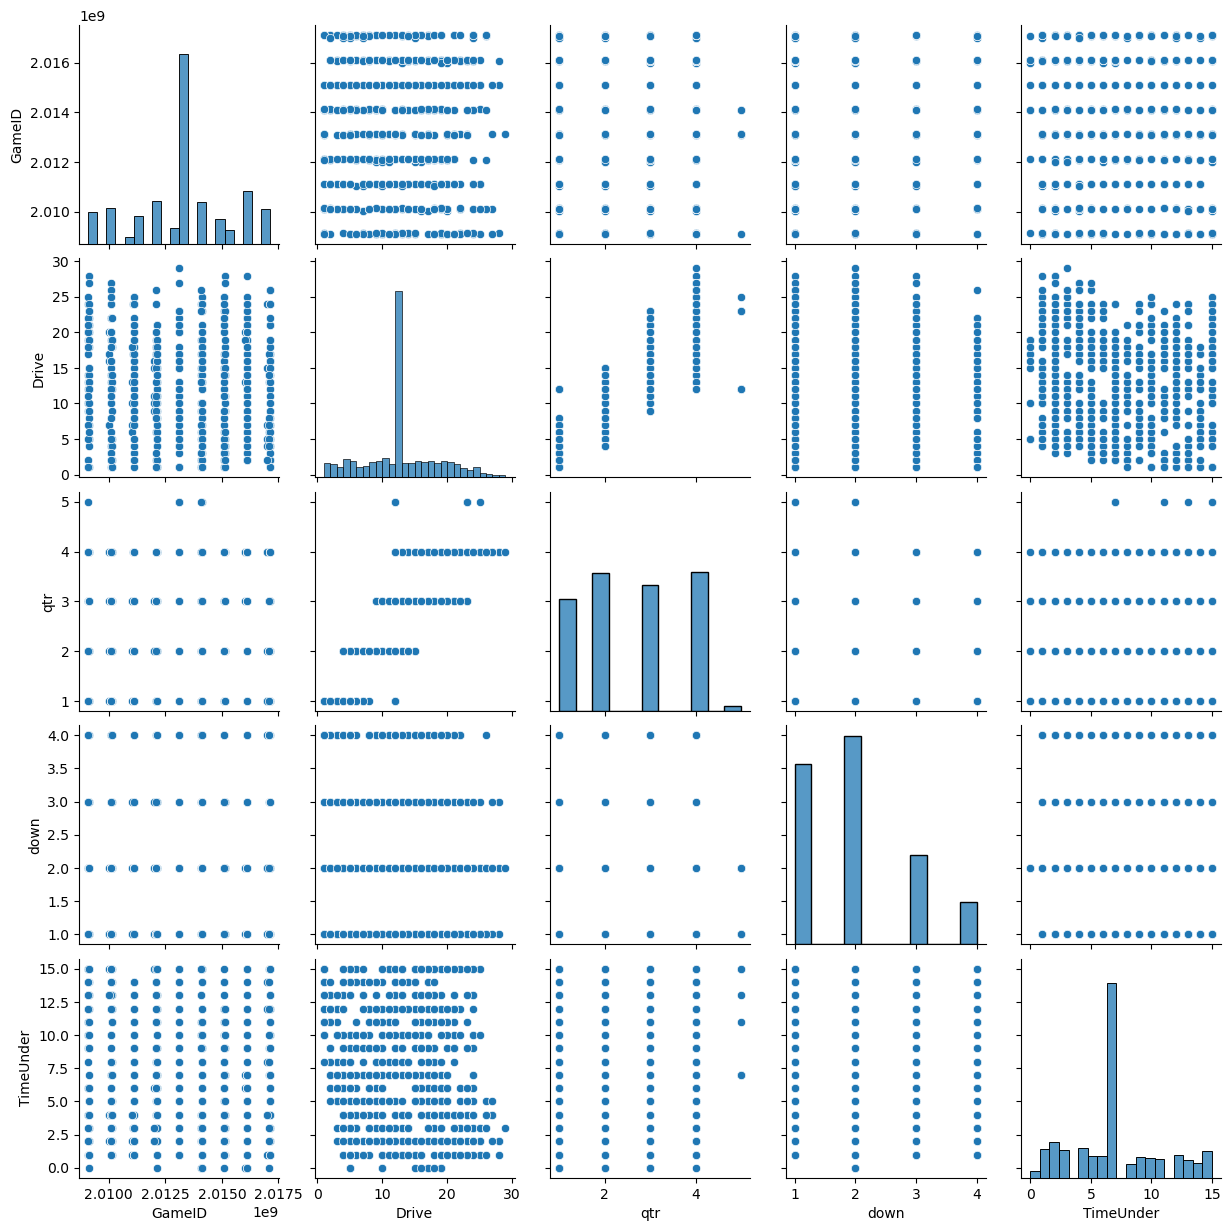

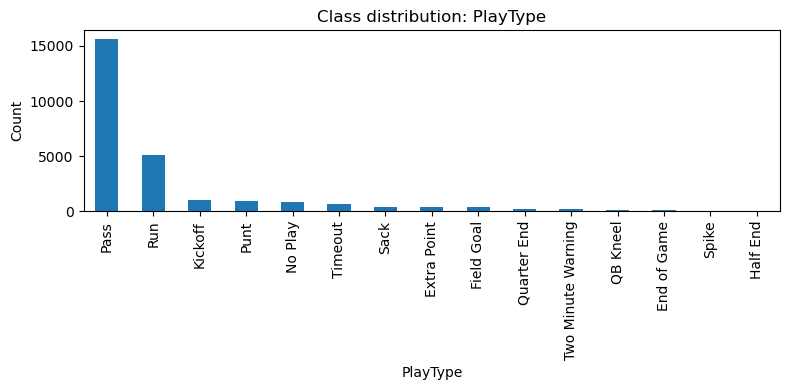

In [8]:
pairplot_cols = list(num_cols[:5])
if len(pairplot_cols) >= 2:
    sns.pairplot(clean_df[pairplot_cols].sample(n=min(1000, len(clean_df)), random_state=42))
    plt.show()

cat_cols = clean_df.select_dtypes(exclude=[np.number]).columns
target_col = None
for col in cat_cols:
    if clean_df[col].nunique() <= 20:
        target_col = col
        break

if target_col is not None:
    plt.figure(figsize=(8, 4))
    clean_df[target_col].value_counts().plot(kind="bar")
    plt.title(f"Class distribution: {target_col}")
    plt.xlabel(target_col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

### 5.3 3D scatter (automatic)

I automatically select three usable numeric columns and plot a 3D scatter view.

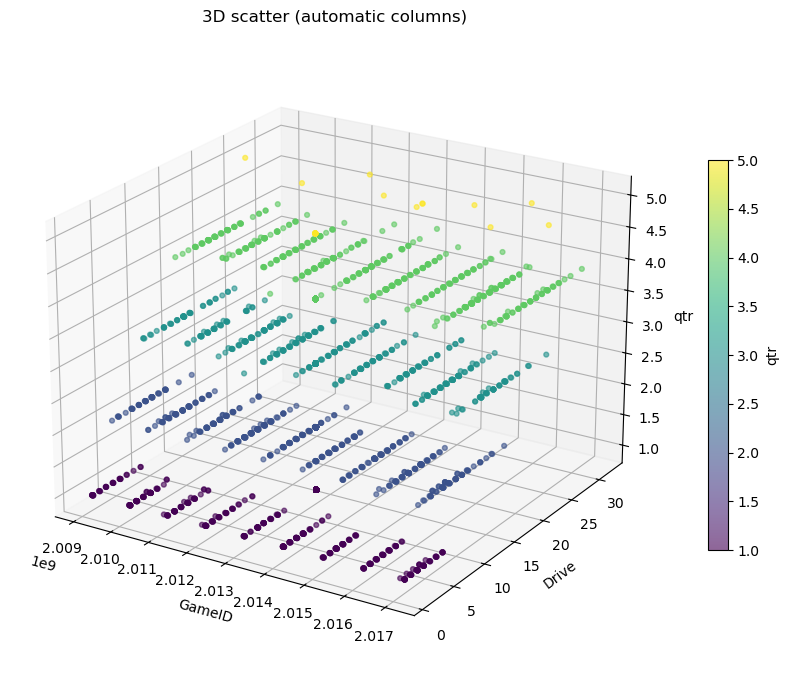

In [9]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

num_all = clean_df.select_dtypes(include=[np.number]).columns.tolist()
usable = []
for c in num_all[:40]:
    if clean_df[c].replace([np.inf, -np.inf], np.nan).dropna().shape[0] >= 100:
        usable.append(c)
    if len(usable) == 3:
        break

if len(usable) == 3:
    c1, c2, c3 = usable
    sub = clean_df[[c1, c2, c3]].replace([np.inf, -np.inf], np.nan).dropna()
    sub = sub.sample(n=min(3000, len(sub)), random_state=42)

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")
    sc = ax.scatter(sub[c1], sub[c2], sub[c3], c=sub[c3], cmap="viridis", s=12, alpha=0.6)
    fig.colorbar(sc, ax=ax, shrink=0.6, label=c3)
    ax.set_xlabel(c1)
    ax.set_ylabel(c2)
    ax.set_zlabel(c3)
    ax.set_title("3D scatter (automatic columns)")
    ax.view_init(elev=22, azim=-58)
    plt.tight_layout()
    plt.show()

### 5.4 3D scatter (manual columns)

I can choose exactly which numeric columns to plot in 3D.

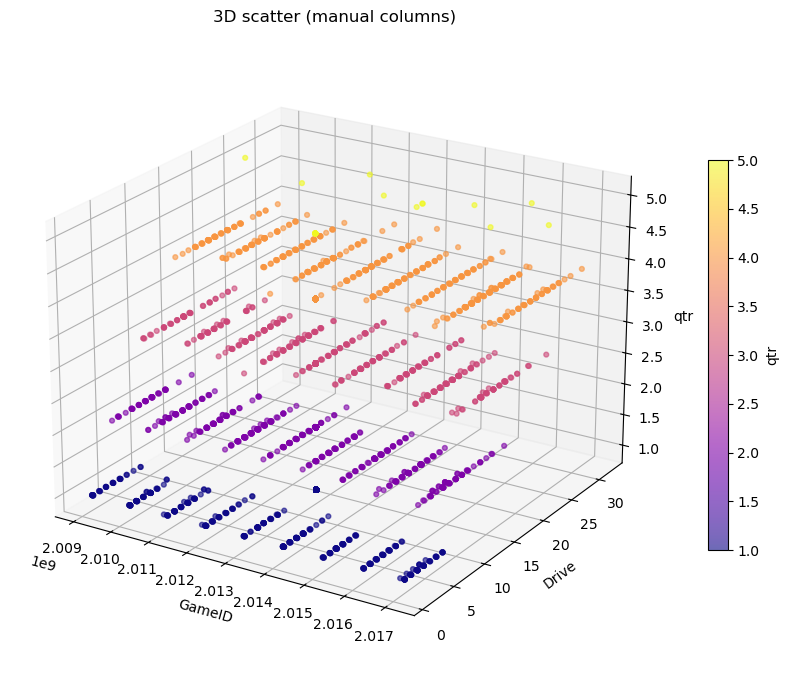

In [10]:
# Choose 3 numeric columns manually
COL_X = num_all[0] if len(num_all) > 0 else None
COL_Y = num_all[1] if len(num_all) > 1 else None
COL_Z = num_all[2] if len(num_all) > 2 else None

if None not in (COL_X, COL_Y, COL_Z):
    sub_m = clean_df[[COL_X, COL_Y, COL_Z]].replace([np.inf, -np.inf], np.nan).dropna()
    sub_m = sub_m.sample(n=min(3000, len(sub_m)), random_state=42)

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")
    sc = ax.scatter(sub_m[COL_X], sub_m[COL_Y], sub_m[COL_Z], c=sub_m[COL_Z], cmap="plasma", s=12, alpha=0.6)
    fig.colorbar(sc, ax=ax, shrink=0.6, label=COL_Z)
    ax.set_xlabel(COL_X)
    ax.set_ylabel(COL_Y)
    ax.set_zlabel(COL_Z)
    ax.set_title("3D scatter (manual columns)")
    ax.view_init(elev=22, azim=-58)
    plt.tight_layout()
    plt.show()

## 6. Interpretation

- The missing-value chart highlights which features are mostly empty and are candidates for removal.
- After imputing and cleaning, numeric distributions are more stable.
- The correlation heatmap and boxplots summarize linear relationships and outliers.
- The pairplot and class distribution provide a compact multivariate view.
- The two 3D plots add a spatial view of relationships among three numeric features.

## 7. Short report

Gémima ONDELE - Msc 1-AI

I loaded all CSV files in `Dataset/` using a chunked pipeline to avoid memory errors. I computed missing values across the full dataset, removed columns above **75%** missing, and imputed remaining gaps with the median (numeric) or mode (categorical) based on a sample. I exported the cleaned dataset in chunks (`Dataset/cleaned_primary_schema.csv.gz`), removing duplicates per chunk for efficiency. The visual analysis includes missing-value charts, distribution plots, correlation/boxplots, pairplot, class distribution, and both automatic and manual 3D scatter views.

---
Gémima ONDELE - Msc 1-AI

## 8. Regenerate styled exports

I run the next cell to regenerate all presentation assets in `linkedin_export/` from the current notebook state. Existing files are replaced so results stay up to date.

In [11]:
from pathlib import Path
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

EXPORT_DIR = Path("linkedin_export")
EXPORT_DIR.mkdir(exist_ok=True)

# Regenerate folder contents from scratch
for p in EXPORT_DIR.glob("*"):
    if p.is_file():
        p.unlink()


def _short(x, n=28):
    s = str(x)
    return s if len(s) <= n else s[: n - 1] + "…"


def save_table_png(df_part, filename, title, max_rows=14, max_cols=10):
    d = df_part.iloc[:max_rows, :max_cols].copy()
    fig_w = max(8, min(14, 2.2 + d.shape[1] * 1.2))
    fig_h = max(6, min(20, 2.6 + d.shape[0] * 0.45))

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")
    ax.set_title(title, fontsize=13, fontweight="bold", pad=16)

    cells = []
    for row in d.values:
        row_fmt = []
        for v in row:
            if isinstance(v, (int, float, np.integer, np.floating)) and pd.notna(v):
                row_fmt.append(f"{v:.5g}")
            else:
                row_fmt.append(_short(v, 36))
        cells.append(row_fmt)

    table = ax.table(
        cellText=cells,
        colLabels=[_short(c, 24) for c in d.columns],
        loc="center",
        cellLoc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)

    for (r, c), cell in table.get_celld().items():
        cell.set_edgecolor("#C5D0DF")
        cell.set_linewidth(0.6)
        if r == 0:
            cell.set_facecolor("#0B5FA8")
            cell.get_text().set_color("white")
            cell.get_text().set_fontweight("bold")
        else:
            cell.set_facecolor("#F7FAFC" if r % 2 == 0 else "white")

    table.scale(1.1, 1.5)
    fig.tight_layout()
    fig.savefig(EXPORT_DIR / filename, dpi=220, bbox_inches="tight", facecolor="white")
    plt.close(fig)


captions = []

def add_caption(file_name, en, fr):
    captions.append({"file": file_name, "en": en, "fr": fr})


# 00) Numeric catalog
num_all = clean_df.select_dtypes(include=[np.number]).columns.tolist()
catalog_df = pd.DataFrame({"i": range(len(num_all)), "numeric_column": num_all})
save_table_png(catalog_df.head(55), "00_table_numeric_catalog.png", "Numeric Column Catalog", max_rows=55, max_cols=2)
add_caption(
    "00_table_numeric_catalog.png",
    "Numeric catalog used to select clear 3D axes by index.",
    "Catalogue numerique utilise pour choisir les axes 3D par indice.",
)

# 01) Missing table
miss_tbl = missing_summary.head(15).reset_index().rename(columns={"index": "feature"})
save_table_png(miss_tbl, "01_table_top_missing.png", "Top 15 Features by Missing Values", max_rows=15, max_cols=3)
add_caption(
    "01_table_top_missing.png",
    "Table of the most incomplete features before cleaning.",
    "Table des variables les plus incompletes avant nettoyage.",
)

# 02) Clean preview
save_table_png(clean_df.head(12), "02_table_clean_head.png", "Cleaned Data Preview", max_rows=12, max_cols=10)
add_caption(
    "02_table_clean_head.png",
    "Preview of the cleaned dataset after imputation and deduplication.",
    "Apercu du jeu nettoye apres imputation et deduplication.",
)

# 03) Missing bar chart
fig, ax = plt.subplots(figsize=(11, 5.5))
top_missing = missing_summary.head(15)
ax.bar(top_missing.index.astype(str), top_missing["missing_percent"], color="#2B6CB0")
ax.set_title("Top 15 Features by Missing Percentage", fontweight="bold")
ax.set_ylabel("Missing percent")
ax.set_xticklabels(top_missing.index.astype(str), rotation=75, ha="right", fontsize=8)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "03_chart_missing_bar.png", dpi=220, bbox_inches="tight")
plt.close(fig)
add_caption(
    "03_chart_missing_bar.png",
    "Bar chart of missing-value rates used to justify the 75% threshold.",
    "Diagramme des taux de valeurs manquantes justifiant le seuil de 75%.",
)

# 04) Histogram
num_cols = clean_df.select_dtypes(include=[np.number]).columns
if len(num_cols) > 0:
    col = num_cols[0]
    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.hist(clean_df[col], bins=35, color="#DD6B20", edgecolor="black")
    ax.set_title(f"Distribution of {col} (Cleaned)", fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    fig.tight_layout()
    fig.savefig(EXPORT_DIR / "04_chart_hist_numeric.png", dpi=220, bbox_inches="tight")
    plt.close(fig)
    add_caption(
        "04_chart_hist_numeric.png",
        f"Histogram of {col} after cleaning.",
        f"Histogramme de {col} apres nettoyage.",
    )

# 05) Correlation heatmap
if len(num_cols) > 1:
    corr = clean_df[num_cols].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title("Correlation Heatmap (Numeric Features)", fontweight="bold")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(EXPORT_DIR / "05_chart_correlation.png", dpi=220, bbox_inches="tight")
    plt.close(fig)
    add_caption(
        "05_chart_correlation.png",
        "Heatmap showing linear relationships among numeric features.",
        "Heatmap montrant les relations lineaires entre variables numeriques.",
    )

# 06) Boxplots
if len(num_cols) > 0:
    cols_for_box = list(num_cols[:5])
    fig, ax = plt.subplots(figsize=(10, 5))
    clean_df[cols_for_box].plot(kind="box", ax=ax)
    ax.set_title("Boxplots of Selected Numeric Features", fontweight="bold")
    ax.set_xticklabels([_short(c, 16) for c in cols_for_box], rotation=25, ha="right")
    fig.tight_layout()
    fig.savefig(EXPORT_DIR / "06_chart_boxplots.png", dpi=220, bbox_inches="tight")
    plt.close(fig)
    add_caption(
        "06_chart_boxplots.png",
        "Boxplots highlighting spread and outliers in selected features.",
        "Boxplots mettant en evidence dispersion et outliers.",
    )

# 07) Pairplot
pair_cols = list(num_cols[:5])
if len(pair_cols) >= 2:
    g = sns.pairplot(clean_df[pair_cols].sample(n=min(700, len(clean_df)), random_state=42))
    g.fig.suptitle("Pairplot (sample)", y=1.02)
    g.savefig(EXPORT_DIR / "07_chart_pairplot.png", dpi=220, bbox_inches="tight")
    plt.close(g.fig)
    add_caption(
        "07_chart_pairplot.png",
        "Pairplot view of pairwise numeric relationships.",
        "Pairplot des relations bivariées entre variables numeriques.",
    )

# 08) Categorical distribution
cat_cols = clean_df.select_dtypes(exclude=[np.number]).columns
target_col = None
for c in cat_cols:
    if clean_df[c].nunique() <= 20:
        target_col = c
        break
if target_col is not None:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    clean_df[target_col].value_counts().plot(kind="bar", ax=ax, color="#2F855A")
    ax.set_title(f"Class distribution: {target_col}", fontweight="bold")
    fig.tight_layout()
    fig.savefig(EXPORT_DIR / "08_chart_categorical.png", dpi=220, bbox_inches="tight")
    plt.close(fig)
    add_caption(
        "08_chart_categorical.png",
        f"Class distribution of {target_col}.",
        f"Distribution des classes pour {target_col}.",
    )

# 09) 3D auto
if len(num_all) >= 3:
    c1, c2, c3 = num_all[0], num_all[1], num_all[2]
    sub = clean_df[[c1, c2, c3]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(sub) > 0:
        sub = sub.sample(n=min(2500, len(sub)), random_state=42)
        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection="3d")
        sc = ax.scatter(sub[c1], sub[c2], sub[c3], c=sub[c3], cmap="viridis", s=12, alpha=0.6)
        fig.colorbar(sc, ax=ax, shrink=0.6, label=c3)
        ax.set_xlabel(c1)
        ax.set_ylabel(c2)
        ax.set_zlabel(c3)
        ax.set_title("3D scatter (automatic)")
        ax.view_init(elev=22, azim=-58)
        plt.tight_layout()
        fig.savefig(EXPORT_DIR / "09_chart_3d_auto.png", dpi=220, bbox_inches="tight")
        plt.close(fig)
        add_caption(
            "09_chart_3d_auto.png",
            "Automatic 3D scatter for quick spatial pattern inspection.",
            "Nuage 3D automatique pour inspecter les structures spatiales.",
        )

# 10) 3D manual (indices 0,1,2)
if len(num_all) >= 3:
    mx, my, mz = num_all[0], num_all[1], num_all[2]
    subm = clean_df[[mx, my, mz]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(subm) > 0:
        subm = subm.sample(n=min(2500, len(subm)), random_state=42)
        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection="3d")
        sc = ax.scatter(subm[mx], subm[my], subm[mz], c=subm[mz], cmap="plasma", s=12, alpha=0.6)
        fig.colorbar(sc, ax=ax, shrink=0.6, label=mz)
        ax.set_xlabel(mx)
        ax.set_ylabel(my)
        ax.set_zlabel(mz)
        ax.set_title("3D scatter (manual indices 0,1,2)")
        ax.view_init(elev=22, azim=-58)
        plt.tight_layout()
        fig.savefig(EXPORT_DIR / "10_chart_3d_catalog_indices.png", dpi=220, bbox_inches="tight")
        plt.close(fig)
        add_caption(
            "10_chart_3d_catalog_indices.png",
            "Manual 3D scatter using chosen numeric indices.",
            "Nuage 3D manuel avec indices numeriques choisis.",
        )

# 11) KPI dashboard image (restructured, no overlaps)
raw_rows = int(total_rows)
raw_cols = len(all_columns)
clean_rows = len(clean_df)
clean_cols = clean_df.shape[1]
removed_cols = len(cols_to_drop)
missing_after = int(clean_df.isna().sum().sum())

raw_size_gb = sum(p.stat().st_size for p in csv_files) / (1024**3)
clean_file = Path(OUTPUT_PATH)
clean_size_gb = clean_file.stat().st_size / (1024**3) if clean_file.exists() else 0.0

num_count = int(clean_df.select_dtypes(include=[np.number]).shape[1])
cat_count = int(clean_df.shape[1] - num_count)

expected_results = [
    "01_table_top_missing.png", "02_table_clean_head.png", "03_chart_missing_bar.png",
    "04_chart_hist_numeric.png", "05_chart_correlation.png", "06_chart_boxplots.png",
    "07_chart_pairplot.png", "08_chart_categorical.png", "09_chart_3d_auto.png",
    "10_chart_3d_catalog_indices.png", "11_kpi_dashboard.png"
]

fig = plt.figure(figsize=(18, 10), facecolor="#0E1117", constrained_layout=True)
gs = fig.add_gridspec(3, 4, height_ratios=[1.0, 1.2, 1.2])
fig.suptitle("KPI Dashboard - Data Preparation Lab", fontsize=22, fontweight="bold", color="white")

# A) KPI text panel
ax_kpi = fig.add_subplot(gs[0, 0])
ax_kpi.set_facecolor("#161B22")
ax_kpi.set_xticks([]); ax_kpi.set_yticks([])
for s in ax_kpi.spines.values():
    s.set_color("#2D333B")
ax_kpi.set_title("Core KPIs", color="white", fontsize=12, pad=8)
kpi_lines = [
    f"Raw rows: {raw_rows:,}",
    f"Raw columns: {raw_cols}",
    f"Removed columns: {removed_cols}",
    f"Clean rows (sample): {clean_rows:,}",
    f"Clean columns: {clean_cols}",
    f"Missing after cleaning: {missing_after:,}",
    f"Raw size: {raw_size_gb:.2f} GB",
    f"Export size: {clean_size_gb:.2f} GB",
]
for i, line in enumerate(kpi_lines):
    ax_kpi.text(0.05, 0.90 - i * 0.10, line, color="#C9D1D9", fontsize=10, transform=ax_kpi.transAxes)

# B) Camembert 1: kept vs removed columns
ax_p1 = fig.add_subplot(gs[0, 1])
ax_p1.set_facecolor("#161B22")
vals_cols = [max(clean_cols, 0), max(removed_cols, 0)]
labels_cols = ["Kept cols", "Removed cols"]
colors_cols = ["#2EA043", "#F85149"]
ax_p1.pie(vals_cols, labels=labels_cols, autopct="%1.1f%%", startangle=90, colors=colors_cols, textprops={"color": "white", "fontsize": 9})
ax_p1.set_title("Column Filtering Impact", color="white", fontsize=11)

# C) Camembert 2: numeric vs categorical columns
ax_p2 = fig.add_subplot(gs[0, 2])
ax_p2.set_facecolor("#161B22")
vals_types = [num_count, cat_count] if (num_count + cat_count) > 0 else [1, 0]
labels_types = ["Numeric", "Categorical"]
colors_types = ["#58A6FF", "#BC8CFF"]
ax_p2.pie(vals_types, labels=labels_types, autopct="%1.1f%%", startangle=90, colors=colors_types, textprops={"color": "white", "fontsize": 9})
ax_p2.set_title("Feature Type Mix (Clean)", color="white", fontsize=11)

# D) Camembert 3: represented results coverage
ax_p3 = fig.add_subplot(gs[0, 3])
ax_p3.set_facecolor("#161B22")
represented = sum((EXPORT_DIR / f).exists() for f in expected_results[:-1])
total_expected = len(expected_results[:-1])
ax_p3.pie(
    [represented, max(total_expected - represented, 0)],
    labels=["Represented", "Missing"],
    autopct="%1.0f%%",
    startangle=90,
    colors=["#3FB950", "#8B949E"],
    textprops={"color": "white", "fontsize": 9},
)
ax_p3.set_title("Notebook Results Coverage", color="white", fontsize=11)

# E) Top missing bar
ax_miss = fig.add_subplot(gs[1, 0:2])
ax_miss.set_facecolor("#161B22")
miss_top = missing_summary.head(8)
ax_miss.bar(miss_top.index.astype(str), miss_top["missing_percent"].values, color="#2EA043")
ax_miss.set_title("Top Missing Features Before Cleaning", color="white", fontsize=11)
ax_miss.set_ylabel("Missing %", color="#C9D1D9")
ax_miss.tick_params(axis="x", rotation=25, labelsize=8, colors="#C9D1D9")
ax_miss.tick_params(axis="y", colors="#C9D1D9")

# F) Histogram
ax_hist = fig.add_subplot(gs[1, 2])
ax_hist.set_facecolor("#161B22")
if len(num_cols) > 0:
    hist_col = num_cols[0]
    ax_hist.hist(clean_df[hist_col], bins=28, color="#58A6FF", edgecolor="#30363D")
    ax_hist.set_title(f"Histogram - {_short(hist_col, 18)}", color="white", fontsize=10)
else:
    ax_hist.text(0.5, 0.5, "No numeric column", ha="center", va="center", color="white")
ax_hist.tick_params(colors="#C9D1D9", labelsize=8)

# G) Categorical distribution
ax_cat = fig.add_subplot(gs[1, 3])
ax_cat.set_facecolor("#161B22")
if target_col is not None:
    vc = clean_df[target_col].value_counts().head(5)
    ax_cat.barh(vc.index.astype(str), vc.values, color="#BC8CFF")
    ax_cat.set_title(f"Class Dist - {_short(target_col, 16)}", color="white", fontsize=10)
    ax_cat.tick_params(colors="#C9D1D9", labelsize=8)
else:
    ax_cat.text(0.5, 0.5, "No low-cardinality\ncategorical feature", ha="center", va="center", color="white")
    ax_cat.set_xticks([]); ax_cat.set_yticks([])

# H-K) Use exact exported visuals (no recomputation artifacts)
def show_export_panel(ax, file_name, title):
    ax.set_facecolor("#161B22")
    ax.set_xticks([])
    ax.set_yticks([])
    for s in ax.spines.values():
        s.set_color("#2D333B")
    ax.set_title(title, color="white", fontsize=10, pad=8)
    p = EXPORT_DIR / file_name
    if p.exists():
        img = plt.imread(p)
        ax.imshow(img)
        ax.set_aspect("auto")
    else:
        ax.text(0.5, 0.5, f"Missing file:\n{file_name}", ha="center", va="center", color="#F85149", fontsize=9)

ax_corr = fig.add_subplot(gs[2, 0])
show_export_panel(ax_corr, "05_chart_correlation.png", "Correlation (from notebook output)")

ax_box = fig.add_subplot(gs[2, 1])
show_export_panel(ax_box, "06_chart_boxplots.png", "Boxplots (from notebook output)")

ax_3d_auto = fig.add_subplot(gs[2, 2])
show_export_panel(ax_3d_auto, "09_chart_3d_auto.png", "3D Auto (from notebook output)")

ax_3d_manual = fig.add_subplot(gs[2, 3])
show_export_panel(ax_3d_manual, "10_chart_3d_catalog_indices.png", "3D Manual (from notebook output)")
fig.savefig(EXPORT_DIR / "11_kpi_dashboard.png", dpi=230, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close(fig)
add_caption(
    "11_kpi_dashboard.png",
    "KPI dashboard consolidating all notebook results with readable panels and pie charts.",
    "Dashboard KPI consolidant tous les resultats du notebook avec panneaux lisibles et camemberts.",
)

# Captions file: English first, then French
lines = ["# LinkedIn Captions\n\n", "## English\n\n"]
for c in captions:
    lines.append(f"- **{c['file']}**: {c['en']}\n")
lines.append("\n## Français\n\n")
for c in captions:
    lines.append(f"- **{c['file']}**: {c['fr']}\n")
(EXPORT_DIR / "captions_bilingual.md").write_text("".join(lines), encoding="utf-8")

# Post template: professional style, no markdown symbols noise
post = [
    "LinkedIn Post Template (Bilingual)\n\n",
    "English\n\n",
    "I completed a full data preparation workflow on large NFL play-by-play datasets, from raw-data quality assessment to a publishable KPI dashboard.\n\n",
    "Method summary\n",
    "- Missing-value audit on the full dataset\n",
    "- Feature filtering with a 75% missing threshold\n",
    "- Median/mode imputation\n",
    "- Deduplication\n",
    "- Structured visual analysis in 2D and 3D\n\n",
    "Carousel reading guide\n",
    "- 00 Numeric catalog for consistent 3D axis selection\n",
    "- 01 Missing table\n",
    "- 02 Cleaned-table preview\n",
    "- 03 Missing-rate bar chart\n",
    "- 04 Histogram\n",
    "- 05 Correlation heatmap\n",
    "- 06 Boxplots\n",
    "- 07 Pairplot\n",
    "- 08 Categorical distribution\n",
    "- 09 Automatic 3D view\n",
    "- 10 Manual 3D view\n",
    "- 11 KPI dashboard consolidating all results\n\n",
    "Key takeaway: robust data preparation improves interpretability and model readiness.\n\n",
    "Hashtags (EN)\n",
    "#DataPreparation #DataCleaning #DataScience #MachineLearning #ComputerVision #Python #Pandas #DataVisualization #StudentProject #OpenToWork\n\n",
    "Français\n\n",
    "J'ai mené un workflow complet de préparation des données sur des jeux NFL volumineux, depuis l'audit de qualité des données brutes jusqu'à un dashboard KPI publiable.\n\n",
    "Résumé de la méthode\n",
    "- Audit des valeurs manquantes sur l'ensemble du dataset\n",
    "- Filtrage des variables avec un seuil de 75%\n",
    "- Imputation (médiane/mode)\n",
    "- Déduplication\n",
    "- Analyse visuelle structurée en 2D et 3D\n\n",
    "Guide de lecture du carrousel\n",
    "- 00 Catalogue numérique pour choisir les axes 3D\n",
    "- 01 Tableau des manquants\n",
    "- 02 Aperçu de la table nettoyée\n",
    "- 03 Diagramme des taux de manquants\n",
    "- 04 Histogramme\n",
    "- 05 Heatmap de corrélation\n",
    "- 06 Boxplots\n",
    "- 07 Pairplot\n",
    "- 08 Distribution catégorielle\n",
    "- 09 Vue 3D automatique\n",
    "- 10 Vue 3D manuelle\n",
    "- 11 Dashboard KPI qui rassemble tous les résultats\n\n",
    "Conclusion: une préparation de données rigoureuse améliore fortement la lisibilité des résultats et la qualité des analyses futures.\n\n",
    "Hashtags (FR)\n",
    "#PreparationDesDonnees #NettoyageDesDonnees #ScienceDesDonnees #ApprentissageAutomatique #VisionParOrdinateur #Python #Pandas #VisualisationDeDonnees #ProjetEtudiant #RechercheStage\n",
]
(EXPORT_DIR / "linkedin_post_template_bilingual.md").write_text("".join(post), encoding="utf-8")

# README (no ZIP export)
readme = ["# Exported Assets\n\n", "Regenerated from current notebook outputs.\n\n"]
for c in captions:
    readme.append(f"- `{c['file']}`\n")
readme.extend([
    "- `captions_bilingual.md`\n",
    "- `linkedin_post_template_bilingual.md`\n",
])
(EXPORT_DIR / "README_exports.md").write_text("".join(readme), encoding="utf-8")

print(f"Regenerated {len(captions)} visual assets in: {EXPORT_DIR.resolve()}")
print("Text files: captions_bilingual.md, linkedin_post_template_bilingual.md")
print("ZIP generation disabled to save disk space.")

C:\Users\gemim\AppData\Local\Temp\ipykernel_24116\3547028590.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_missing.index.astype(str), rotation=75, ha="right", fontsize=8)


Regenerated 12 visual assets in: C:\Users\gemim\OneDrive\Bureau\M1-cours-Data engineer\MSC 1 AI\Semestre 2\Introduction to Computer Vision\Exercises\Data-cleaning_exercise\linkedin_export
Text files: captions_bilingual.md, linkedin_post_template_bilingual.md
ZIP generation disabled to save disk space.
